In [1]:
import sys, os
# Make the in-tree package importable without pip install -e .
_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir, 'src'))
if _ROOT not in sys.path:
    sys.path.insert(0, _ROOT)


# Motion analysis on an encoded polyline

Demo for `sameer_graph_lib.motion` on a sample polyline (~36 points around Gurugram, India), using a 5-second sampling interval.

We'll exercise both function families:
- **Encoded-string input** (`get_max_speed`, `max_accelaration`, `compute_speeds`, `smooth_speeds_fft`, `compute_accelerations`)
- **Timestamped input** (`*_from_timestamps`) using a synthetic time-series built from the same trace

> Note on units: `get_max_speed` and `max_accelaration` use **km/h** and **km/(h·s)**. The `compute_*` and `smooth_*` family use **m/s** and **m/s²**.


In [2]:
import sameer_graph_lib as sgl

POLYLINE = 'g_olDq{juMiBaBiCtBq@l@gA|A}AdB{AjBU^}CtDk@h@oAAs@`AaA~AbJnIzGvGn@v@tFpFhBnB`BzAxA|AlAdAfDjCfExCv@r@Z`@h@Sh@q@XClA?VT|@|@TXBPGNkArA_BeB'
INTERVAL_S = 5.0

decoded = sgl.decode_polyline(POLYLINE)
print(f'{len(decoded)} points decoded')
print(f'first: {decoded[0]}')
print(f'last:  {decoded[-1]}')


36 points decoded
first: (28.42628, 77.06569)
last:  (28.42176, 77.05319)


## 1. Multi-stride max speed (km/h)

`get_max_speed` looks at strides of length 1..max_bucket. The longer strides
average over more samples, so they suppress single-sample GPS jitter.

In [3]:
ms = sgl.get_max_speed(POLYLINE, INTERVAL_S, max_bucket=5)
for k, v in ms.items():
    print(f'stride {k!s:>3}: {v:7.2f} km/h')

stride   1:  184.98 km/h
stride   2:  167.63 km/h
stride   3:  120.89 km/h
stride   4:  123.18 km/h
stride   5:  110.11 km/h
stride all:  184.98 km/h


## 2. Max acceleration / deceleration

`max_accelaration` returns ``{max, min}`` in km/(h·s). ``min`` is the strongest deceleration.

In [4]:
acc = sgl.max_accelaration(POLYLINE, INTERVAL_S)
print(f"max accel: {acc['max']:+.2f} km/(h·s)")
print(f"max decel: {acc['min']:+.2f} km/(h·s)")

max accel: +28.42 km/(h·s)
max decel: -24.56 km/(h·s)


## 3. Per-sample speed series in m/s, with FFT smoothing

`compute_speeds` gives the raw per-segment speed.
`smooth_speeds_fft` applies a Gaussian low-pass in the frequency domain over a 9-sample sliding window — useful when GPS jitter inflates the raw max.

In [5]:
speeds_raw = sgl.compute_speeds(POLYLINE, INTERVAL_S)
speeds_smooth = sgl.smooth_speeds_fft(POLYLINE, INTERVAL_S)

print(f'samples:        {len(speeds_raw)}')
print(f'raw max:        {max(speeds_raw):.2f} m/s  ({max(speeds_raw)*3.6:.1f} km/h)')
print(f'raw mean:       {sum(speeds_raw)/len(speeds_raw):.2f} m/s')
print(f'smoothed max:   {max(speeds_smooth):.2f} m/s  ({max(speeds_smooth)*3.6:.1f} km/h)')
print(f'dominant freq:  {sgl.dominant_frequency_hz(POLYLINE, INTERVAL_S):.4f} Hz')

samples:        35
raw max:        51.38 m/s  (185.0 km/h)
raw mean:       13.47 m/s
smoothed max:   41.74 m/s  (150.3 km/h)
dominant freq:  0.0057 Hz


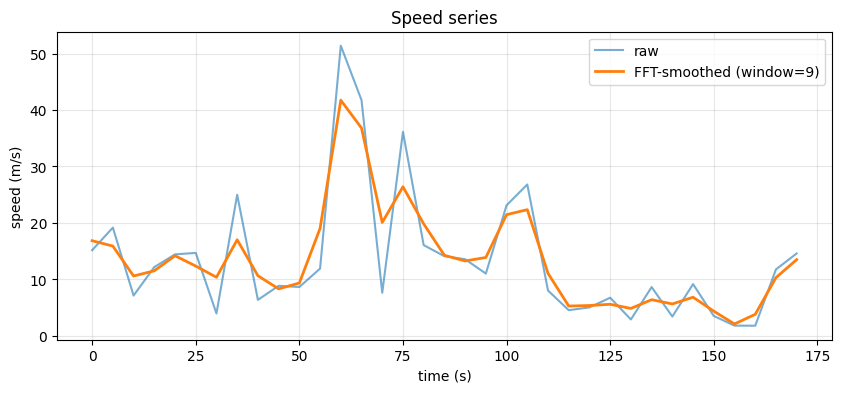

In [6]:
# Plot raw vs smoothed if matplotlib is available
try:
    import matplotlib.pyplot as plt
    t = [i * INTERVAL_S for i in range(len(speeds_raw))]
    plt.figure(figsize=(10, 4))
    plt.plot(t, speeds_raw, label='raw', alpha=0.6)
    plt.plot(t, speeds_smooth, label='FFT-smoothed (window=9)', linewidth=2)
    plt.xlabel('time (s)')
    plt.ylabel('speed (m/s)')
    plt.title('Speed series')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
except ImportError:
    print('matplotlib not installed; skipping plot')

## 4. Acceleration series and braking detection

`compute_accelerations` gives per-sample acceleration in m/s². Negative values are deceleration.

In [7]:
accels = sgl.compute_accelerations(POLYLINE, INTERVAL_S)
print(f'samples:           {len(accels)}')
print(f'max acceleration:  {max(accels):+7.2f} m/s²')
print(f'max deceleration:  {min(accels):+7.2f} m/s²')

# Top 5 hardest braking events (by index)
events = sorted(enumerate(accels), key=lambda x: x[1])[:5]
print('\ntop 5 hardest braking samples (sample idx, deceleration m/s²):')
for i, a in events:
    print(f'  idx {i:>2}  t={(i+1)*INTERVAL_S:>5.0f}s  a={a:+.2f}')

samples:           34
max acceleration:    +7.89 m/s²
max deceleration:    -6.82 m/s²

top 5 hardest braking samples (sample idx, deceleration m/s²):
  idx 13  t=   70s  a=-6.82
  idx 15  t=   80s  a=-4.01
  idx 21  t=  110s  a=-3.76
  idx  7  t=   40s  a=-3.72
  idx  1  t=   10s  a=-2.41


## 5. Timestamped path (non-uniform sampling)

To demonstrate the `*_from_timestamps` variant, attach synthetic timestamps to the decoded points (5 s apart, except a deliberately-doubled gap mid-trace).

In [8]:
# Build a (lat, lng, t) trace; widen one segment to 10 s to simulate a GPS dropout.
times = []
t = 0.0
for i, _ in enumerate(decoded):
    times.append(t)
    t += 10.0 if i == 12 else INTERVAL_S
timed = [(lat, lng, ts) for (lat, lng), ts in zip(decoded, times)]

speeds_t = sgl.compute_speeds_from_timestamps(timed)
accels_t = sgl.compute_accelerations_from_timestamps(timed)
brakes = sgl.detect_sudden_braking_from_timestamps(timed, threshold_mps2=-3.0)

print(f'speeds:        {len(speeds_t)} samples, max = {max(speeds_t):.2f} m/s')
print(f'accels:        {len(accels_t)} samples, max = {max(accels_t):+.2f}, min = {min(accels_t):+.2f} m/s²')
print(f'sudden brakes: {len(brakes)} event(s) at threshold -3.0 m/s²')
for ev in brakes[:5]:
    print(f"  t={ev['time_s']:>5.1f}s (idx {ev['index']}):  {ev['deceleration_mps2']:+.2f} m/s²")

speeds:        35 samples, max = 41.75 m/s
accels:        34 samples, max = +5.70, min = -6.82 m/s²
sudden brakes: 4 event(s) at threshold -3.0 m/s²
  t= 40.0s (idx 8):  -3.72 m/s²
  t= 75.0s (idx 14):  -6.82 m/s²
  t= 85.0s (idx 16):  -4.01 m/s²
  t=115.0s (idx 22):  -3.76 m/s²


## Important caveat

The values above are computed assuming consecutive polyline points are exactly `INTERVAL_S` seconds apart. **Encoded polylines from routing APIs (Google Directions, Mapbox, etc.) are sampled by *shape*, not by *time*** — points cluster on curves and spread on straights. So speeds and accelerations from a route-shape polyline are **not real driver behavior**; they're an artifact of the encoding.

For meaningful results, feed in either:

1. A real GPS log uniformly sampled at a known interval, or
2. A `(lat, lng, t_seconds)` trace into the `*_from_timestamps` family — those use each segment's actual `Δt`.